In [1]:
import os, sys
sys.path.append('../src')
from FIT_python.data_split_and_summary.datasplit_and_summary_wraper import prepare_all_splits

# Daten-Splits sind bereits vorhanden, Aufruf bei Bedarf:
#prepare_all_splits()

In [ ]:
from FIT_python.plot_style import apply_style

apply_style()
import pandas as pd
from pathlib import Path
from FIT_python.pipeline_individual_id.utils import sequential_holdout_ids
from FIT_python.pipeline_individual_id.geometric_pairwise_projection import (
    generate_pairwise_comparisons_from_df,
)
from FIT_python.pipeline_individual_id.baseline_pipeline import DistanceBaseline
from FIT_python.pipeline_individual_id.supervised_umap_pipeline import run as run_umap

from FIT_python.pipeline_individual_id.siamese_pipeline import run as run_siamese
from FIT_python.pipeline_individual_id.evaluation import compute_confusion
import seaborn as sns, matplotlib.pyplot as plt
from FIT_python.data_split_and_summary.data_import_utils import (
    load_and_prep_df_individual,
    get_feature_cols,
)
from FIT_python.config import RESULTS_DATA_DIR, SPLITS_DIR


# %% 1) Basis-Pfade & Hyperparameter-Räume (unverändert)
splits_root = Path("data/splits/eurasian_otter")
models_root = (
    RESULTS_DATA_DIR
    / "eurasian_otter_random_search_standard_metrics"
    / "best_maj_test_pct"
)
output_root = Path("results/data/pairwise_comp_eurasian_otter")
output_root.mkdir(parents=True, exist_ok=True)

# 6) Loop über Spezies
species_dir = Path(SPLITS_DIR) / "eurasian_otter"
species = "eurasian_otter"
print(f"\n🔄 Processing species: {species}")

# 6.1) Train/Test laden & Fold entfernen
df = load_and_prep_df_individual(
    species, Path(SPLITS_DIR)
)  # falls hier bugs valid vales f und m checken

feature_cols = [
    c for c in df.columns if c.startswith(("dist", "ang", "t", "v")) and c != "trail"
]
ids = df["individual_id"].unique()
split = sequential_holdout_ids(ids, val_sizes=[3, 5, 9], n_iter=5, random_state=0)[0]
train_df = df[df["individual_id"].isin(split["train_ids"])]
val_df = df[df["individual_id"].isin(split["val_ids"])]
val_comps = generate_pairwise_comparisons_from_df(
    val_df,
    id_col="individual_id",
    group_sizes=[ 2,3,5, 7],
    n_repeats=10,
    mode="both",
    selfmatch_factor=2.0,
    n_folds=3,
    random_state=42,
    show_progress=True,
)

# In ein DataFrame überführen
df_val_comps = pd.DataFrame(val_comps)

c:\Users\Frede\miniconda3\envs\FIT_python_conda_env\Lib\site-packages\tqdm_joblib\__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm



🔄 Processing species: eurasian_otter


In [3]:
val_comps

[{'ind_a': 'leni',
  'ind_b': 'zewe',
  'samples_a': [2606, 2605],
  'samples_b': [2701, 2696],
  'trail_a_id': 'leni_2a',
  'trail_b_id': 'zewe_2a',
  'same_individual': False,
  'fold': 0},
 {'ind_a': 'leni',
  'ind_b': 'zewe',
  'samples_a': [2612, 2601],
  'samples_b': [2694, 2701],
  'trail_a_id': 'leni_2b',
  'trail_b_id': 'zewe_2b',
  'same_individual': False,
  'fold': 0},
 {'ind_a': 'leni',
  'ind_b': 'zewe',
  'samples_a': [2608, 2606],
  'samples_b': [2694, 2691],
  'trail_a_id': 'leni_2c',
  'trail_b_id': 'zewe_2c',
  'same_individual': False,
  'fold': 0},
 {'ind_a': 'leni',
  'ind_b': 'zewe',
  'samples_a': [2611, 2610],
  'samples_b': [2705, 2689],
  'trail_a_id': 'leni_2d',
  'trail_b_id': 'zewe_2d',
  'same_individual': False,
  'fold': 0},
 {'ind_a': 'leni',
  'ind_b': 'zewe',
  'samples_a': [2607, 2605],
  'samples_b': [2704, 2696],
  'trail_a_id': 'leni_2e',
  'trail_b_id': 'zewe_2e',
  'same_individual': False,
  'fold': 0},
 {'ind_a': 'leni',
  'ind_b': 'zewe',
  

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from FIT_python.pipeline_individual_id.baseline_pipeline import DistanceBaseline
from FIT_python.pipeline_individual_id.evaluation import compute_confusion

splits = sequential_holdout_ids(ids, val_sizes=[3, 5, 9], n_iter=10, random_state=0)

for split in splits:
    train_df = df[df["individual_id"].isin(split["train_ids"])]
    val_df   = df[df["individual_id"].isin(split["val_ids"])]
    val_comps = generate_pairwise_comparisons_from_df(
        val_df, id_col="individual_id", group_sizes=[7],
        n_repeats=2, mode="both", selfmatch_factor=2.0,
        n_folds=2, random_state=42, show_progress=True,
    )

    res_base = DistanceBaseline.run(train_df, val_comps, feature_cols, val_df=val_df)
    Xb = res_base.filter(regex="^dist_")
    yb = res_base["same_individual"].map({"True": 1, "False": 0})

    cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
    lr = LogisticRegression(max_iter=200)
    y_pred = cross_val_predict(lr, Xb, yb, cv=cv)

    cm_base = compute_confusion(pd.DataFrame({"same_individual": yb, "pred": y_pred}))
    print(f"Iteration {split['iteration']}, n_val={split['n_val']}")
    display(cm_base)

Processing Pairs:   0%|          | 0/14 [00:00<?, ?it/s]

  0%|          | 0/14 [00:00<?, ?it/s]

Iteration 0, n_val=3


,pred_same,pred_diff
true_same,8,0
true_diff,0,6




c:\Users\Frede\miniconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
Processing Pairs:   0%|          | 0/16 [00:00<?, ?it/s]

...

  0%|          | 0/68 [00:00<?, ?it/s]

Iteration 4, n_val=9


,pred_same,pred_diff
true_same,7,5
true_diff,0,56




Processing Pairs:   0%|          | 0/68 [00:07<?, ?it/s]


ValueError: n_splits=2 cannot be greater than the number of members in each class.

c:\Users\Frede\miniconda3\envs\FIT_python_conda_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
Processing Pairs:   0%|          | 0/1240 [02:36<?, ?it/s]


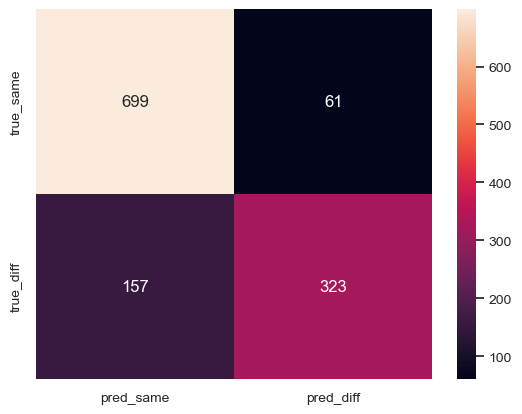

In [5]:
res_umap, emb_umap = run_umap(train_df, val_comps, feature_cols, val_df=val_df)
yu = res_umap["same_individual"].map({"True": 1, "False": 0})
pred_u = (res_umap["pred_same_proba"] > 0.5).astype(int)
res_umap["pred"] = (res_umap["pred_same_proba"] > 0.5).astype(int)
cm_umap = compute_confusion(res_umap, true_col="same_individual", pred_col="pred")

sns.heatmap(cm_umap, annot=True, fmt="d")
plt.show()

In [6]:
# Siamese-Pipeline aktuell deaktiviert
res_siam = run_siamese(train_df, val_comps, feature_cols)
ys = pd.Series([c["same_individual"] for c in val_comps]).map({"True": 1, "False": 0})
pred_s = (pd.Series([r["pred_same"] for r in res_siam]) > 0.5).astype(int)
cm_siam = compute_confusion(pd.DataFrame({"same_individual": ys, "pred": pred_s}))
sns.heatmap(cm_siam, annot=True, fmt="d")
plt.show()

KeyError: "ID '2606' not found in embeddings DataFrame"